In [8]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Any
from langchain_tavily import TavilySearch
from rich import print
from langchain_cohere import ChatCohere

In [68]:
class GraphState(TypedDict):
    query: str
    documents: Any
    confidence: float
    feedback: str
    web: Any
    score: float
    report: str

In [ ]:
import os

os.environ["COHERE_API_KEY"] = ""

llm = ChatCohere()

In [ ]:
os.environ["TAVILY_API_KEY"] = ""

In [71]:
web_search_tool = TavilySearch()

In [72]:
from langchain_community.document_loaders import PyPDFLoader

In [73]:
pdf = PyPDFLoader(file_path="resume.pdf")

In [74]:
documents = pdf.load()

In [75]:
print(documents)

[
    Document(
        metadata={
            'producer': 'Skia/PDF m148 Google Docs Renderer',
            'creator': 'PyPDF',
            'creationdate': '',
            'title': 'Divyanshu Yadav',
            'source': 'resume.pdf',
            'total_pages': 1,
            'page': 0,
            'page_label': '1'
        },
        page_content='Divyanshu  Yadav  Software  Engineer  divyanshu.1810@gmail.com  |  +91  9554469077  |  
Hyderabad,  India  Linkedin  |  LeetCode  |  GitHub  |  Portfolio  |  Blog  Education  SRM  Institute  of  Science 
&  Technology  Computer  Science  Bachelor  of  Technology  CGPA:  9.61  Experience  Kattankulathur,  Chennai,  
India  September  2021  -  June  2025  Infosys  |  Specialist  Programmer  Mysore,  India  |  January  2026  -  
Present  Built  an  Agentic  AI-powered  multilingual  invoice  auditing  system  using  AWS  Bedrock,  LangChain, 
and  LangGraph,  automating  OCR,  validation,  and  anomaly  detectionreducing  manual  eort  by  70%  and  
improving  processing  speed  by  3.  Engineered  a  scalable  RAG-based  pipeline  with  FastAPI  and  Streamlit, 
enabling  real-time  auditing  of  5K+  invoices/month  and  improving  discrepancy  detection  accuracy  by  40%. 
Implemented  adaptive  RAG  and  self-reective  agents,  increasing  audit  accuracy  by  30%  and  reducing  false
positives  by  25%.  Seo  Stack  |  Software  Development  Engineer  -  I  Hyderabad,  India  |  June  2025  -  
December  2025  Led  migration  from  React  to  Next.js  (SSG  +  pre-rendering),  improving  page  load  time  by
45%,  increasing  organic  trac  by  25%,  and  boosting  SEO  rankings  (avg  position  30%).  Built  a  keyword  
analytics  and  experimentation  platform  (10K+  keywords,  50+  domains)  using  Google  Search  Console  APIs,  
reducing  manual  reporting  by  70%  and  improving  SEO  decision  eciency  by  40%  with  data-driven  insights.
Developed  an  AI-powered  support  chatbot  with  streaming  responses,  resolving  60%  of  queries  autonomously
and  reducing  average  issue  resolution  time  by  35%.  Skills  Programming  Languages:  Libraries/Frameworks:  
Tools  /  Platforms:  Databases:  Java,  TypeScript,  JavaScript,  Python  React.js,  Next.js,  Express.js,  
GraphQL,  React  Native,  Spring  Boot,  LangChain,  LangGraph,  Numpy,  Pandas  Git,  GitHub,  CI/CD,  Apache  
Kafka,  Docker,  Generative  AI,  AWS,  RabbitMQ,  Sanity  CMS  PostgreSQL,  MongoDB,  DynamoDB,  Firebase,  
Supabase,  Redis,  Chroma,  FAISS  Projects  /  Open-Source  HealthCare+  |  Link  Next  JS,  AWS  CDK,  Python,  
RDS,  Lambda,  S3,  Cognito  Architected  and  built  a  serverless  healthcare  platform  using  AWS  and  
Next.js,  reducing  report  interpretation  time  by  60%  and  improving  accessibility  with  multilingual  
support.  Developed  scalable  Lambda-based  microservices  for  authentication,  secure  le  uploads,  and  PDF  
analysis,  handling  10K+  documents/month  with  low-latency  processing  and  end-to-end  secure  workows  (IAM, 
JWT,  presigned  URLs).  Integrated  and  optimized  Gemini-powered  AI  for  summarization  and  conversational  
Q&A,  reducing  model  size  by  90%,  improving  response  time  by  35%,  and  increasing  user  engagement  by  
40%.  Llama-Scholar  |  Link  WhatsApp  Hook,  Python,  Llama,  Gen  AI  Built  a  WhatsApp-based  AI  study  
assistant  using  LLaMA,  RAG,  and  LangChain,  enabling  multimodal  summarization  (text,  audio,  image)  and  
context-aware  responses.  Improved  student  query  resolution  time  by  60%  through  semantic  retrieval  and  
personalized  answer  generation.  Authenticheck  |  Link  Flutter,  OpenCV,  Python,  TypeScript,  WebRTCBuilt  an
AI-powered  hiring  integrity  platform  using  computer  vision  and  \nNLP,\n \nreducing\n \ninterview\n 
malpractice  by  35%  through  real-time  monitoring  and  anomaly  detection.  Automated  interview  scheduling  
and  monitoring  worko

In [76]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [77]:

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
    separators=["\n\n", "\n", ".", " ", ""]
)

In [78]:
document = splitter.split_documents(documents)

In [79]:
from langchain_community.vectorstores import Chroma

In [80]:
print(document)

[
    Document(
        metadata={
            'producer': 'Skia/PDF m148 Google Docs Renderer',
            'creator': 'PyPDF',
            'creationdate': '',
            'title': 'Divyanshu Yadav',
            'source': 'resume.pdf',
            'total_pages': 1,
            'page': 0,
            'page_label': '1'
        },
        page_content='Divyanshu  Yadav  Software  Engineer  divyanshu.1810@gmail.com  |  +91  9554469077  |  
Hyderabad,  India  Linkedin  |  LeetCode  |  GitHub  |  Portfolio  |  Blog  Education  SRM  Institute  of  Science 
&  Technology  Computer  Science  Bachelor  of  Technology  CGPA:  9.61  Experience  Kattankulathur,  Chennai,  
India  September  2021  -  June  2025  Infosys  |  Specialist  Programmer  Mysore,  India  |  January  2026  -  
Present  Built  an  Agentic  AI-powered  multilingual  invoice  auditing  system  using  AWS  Bedrock,  LangChain, 
and  LangGraph,  automating  OCR,  validation,  and  anomaly  detectionreducing  manual  eort  by  70%  and  
improving  processing  speed  by  3.  Engineered  a  scalable  RAG-based  pipeline  with  FastAPI  and  Streamlit, 
enabling  real-time  auditing  of  5K+  invoices/month  and  improving  discrepancy  detection  accuracy  by  40%'
    ),
    Document(
        metadata={
            'producer': 'Skia/PDF m148 Google Docs Renderer',
            'creator': 'PyPDF',
            'creationdate': '',
            'title': 'Divyanshu Yadav',
            'source': 'resume.pdf',
            'total_pages': 1,
            'page': 0,
            'page_label': '1'
        },
        page_content='.  Implemented  adaptive  RAG  and  self-reective  agents,  increasing  audit  accuracy  by  
30%  and  reducing  false  positives  by  25%.  Seo  Stack  |  Software  Development  Engineer  -  I  Hyderabad,  
India  |  June  2025  -  December  2025  Led  migration  from  React  to  Next.js  (SSG  +  pre-rendering),  
improving  page  load  time  by  45%,  increasing  organic  trac  by  25%,  and  boosting  SEO  rankings  (avg  
position  30%).  Built  a  keyword  analytics  and  experimentation  platform  (10K+  keywords,  50+  domains)  
using  Google  Search  Console  APIs,  reducing  manual  reporting  by  70%  and  improving  SEO  decision  eciency
by  40%  with  data-driven  insights.  Developed  an  AI-powered  support  chatbot  with  streaming  responses,  
resolving  60%  of  queries  autonomously  and  reducing  average  issue  resolution  time  by  35%'
    ),
    Document(
        metadata={
            'producer': 'Skia/PDF m148 Google Docs Renderer',
            'creator': 'PyPDF',
            'creationdate': '',
            'title': 'Divyanshu Yadav',
            'source': 'resume.pdf',
            'total_pages': 1,
            'page': 0,
            'page_label': '1'
        },
        page_content='.  Skills  Programming  Languages:  Libraries/Frameworks:  Tools  /  Platforms:  Databases:  
Java,  TypeScript,  JavaScript,  Python  React.js,  Next.js,  Express.js,  GraphQL,  React  Native,  Spring  Boot, 
LangChain,  LangGraph,  Numpy,  Pandas  Git,  GitHub,  CI/CD,  Apache  Kafka,  Docker,  Generative  AI,  AWS,  
RabbitMQ,  Sanity  CMS  PostgreSQL,  MongoDB,  DynamoDB,  Firebase,  Supabase,  Redis,  Chroma,  FAISS  Projects  /
Open-Source  HealthCare+  |  Link  Next  JS,  AWS  CDK,  Python,  RDS,  Lambda,  S3,  Cognito  Architected  and  
built  a  serverless  healthcare  platform  using  AWS  and  Next.js,  reducing  report  interpretation  time  by  
60%  and  improving  accessibility  with  multilingual  support.  Developed  scalable  Lambda-based  microservices 
for  authentication,  secure  le  uploads,  and  PDF  analysis,  handling  10K+  documents/month  with  low-latency
processing  and  end-to-end  secure  workows  (IAM,  JWT,  presigned  URLs)'
    ),
    Document(
        metadata={
            'producer': 'Skia/PDF m148 Google Docs Renderer',
            'creator': 'PyPDF',
            'creationdate': '',
            'title': 'Div

In [81]:
from langchain_cohere import CohereEmbeddings

embeddings = CohereEmbeddings(
    model="embed-english-v3.0"
)

chroma = Chroma.from_documents(document, embedding=embeddings)

In [82]:
retreiver = chroma.as_retriever()

In [83]:
def query_node(state):
    query = state["query"]
    documents = retreiver.invoke(query)

    return {
        "documents": documents
    }

In [84]:
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver
from uuid import uuid4

In [112]:
def document_rate_node(state):
    prompt = f"""
You are document analyzer agent, user will be sharing documents and query, please rate documents on the basis of whether they have the correct
answer for the query or not, and RETURN only a number between 0 - 1, please don't return any other text but the number.
documents: {state["documents"]}
query: {state["query"]}
    """

    confidence = float(llm.invoke(prompt).content)

    return {
        "confidence": confidence
    }

In [113]:
def web_searh_node(state):
    web = web_search_tool.invoke(state["query"])

    return {
        "web": web
    }

In [114]:
def web_rate_node(state):
    prompt = f"""
You are document analyzer agent, user will be sharing web data and query, please rate web data on the basis of whether they have the correct
answer for the query or not, and RETURN only a number between 0 - 1, please don't return any other text but the number.
web data: {state["web"]}
query: {state["query"]}
    """

    confidence = float(llm.invoke(prompt).content)

    return {
        "score": confidence
    }

In [115]:
def feedback_node(state):
    feedback = interrupt({
        "question": "The document as well as the web seems to respond not well please review",
        "data": {
            "web": state["web"],
            "documents": state["documents"]
        }
    })

    return {
        "feedback": feedback
    }

In [116]:
def report_generate(state):
    prompt = f"""
You are a reporter agent, please read all these data and generate a conclusive report using these data:
query: {state["query"]}
documents: {state["documents"]}
confidence: {state["confidence"]}
web: {state.get("web", None)}
feedback: {state.get("feedback", None)}
    """

    report = llm.invoke(prompt).content

    return {
        "report": report
    }

In [117]:
def confidence_router(state):
    if (state["confidence"] < 0.75):
        return "web search"
    return "report generate"

In [118]:
def score_router(state):
    if (state["score"] < 0.75):
        return "human review"
    return "report generate"

In [119]:
graph = StateGraph(GraphState)

In [120]:
graph.add_node("query", query_node)
graph.add_node("rate document", document_rate_node)
graph.add_node("web search", web_searh_node)
graph.add_node("rate web", web_rate_node)
graph.add_node("feedback", feedback_node)
graph.add_node("report", report_generate)

In [121]:
graph.set_entry_point("query")
graph.add_edge("query", "rate document")
graph.add_conditional_edges("rate document", confidence_router, {
    "web search": "web search",
    "report generate": "report"
})
graph.add_edge("web search", "rate web")
graph.add_conditional_edges("rate web", score_router, {
    "human review": "feedback",
    "report generate": "report"
})
graph.add_edge("feedback", "report")

In [122]:
app = graph.compile(checkpointer=InMemorySaver())

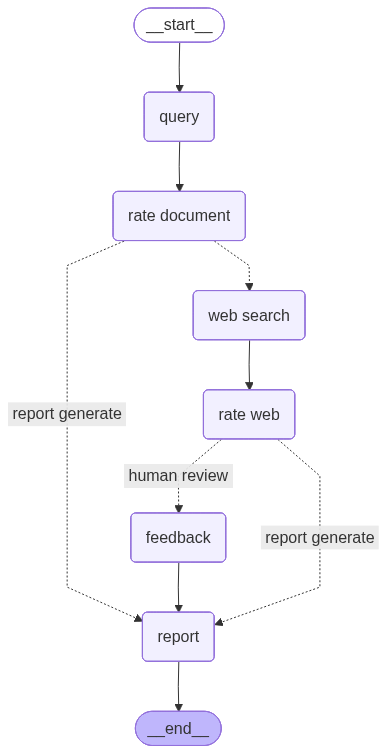

In [123]:
app

In [124]:
config = {
    "configurable": {
        "thread_id": uuid4()
    }
}

In [125]:
result = app.invoke(
    {"query": "who is Divyanshu Yadav"},
    config=config
)

In [126]:
print(result)

{
    'query': 'who is Divyanshu Yadav',
    'documents': [
        Document(
            metadata={
                'creationdate': '',
                'source': 'resume.pdf',
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'creator': 'PyPDF',
                'total_pages': 1,
                'title': 'Divyanshu Yadav',
                'page_label': '1',
                'page': 0
            },
            page_content='Divyanshu  Yadav  Software  Engineer  divyanshu.1810@gmail.com  |  +91  9554469077  |  
Hyderabad,  India  Linkedin  |  LeetCode  |  GitHub  |  Portfolio  |  Blog  Education  SRM  Institute  of  Science 
&  Technology  Computer  Science  Bachelor  of  Technology  CGPA:  9.61  Experience  Kattankulathur,  Chennai,  
India  September  2021  -  June  2025  Infosys  |  Specialist  Programmer  Mysore,  India  |  January  2026  -  
Present  Built  an  Agentic  AI-powered  multilingual  invoice  auditing  system  using  AWS  Bedrock,  LangChain, 
and  LangGraph,  automating  OCR,  validation,  and  anomaly  detectionreducing  manual  eort  by  70%  and  
improving  processing  speed  by  3.  Engineered  a  scalable  RAG-based  pipeline  with  FastAPI  and  Streamlit, 
enabling  real-time  auditing  of  5K+  invoices/month  and  improving  discrepancy  detection  accuracy  by  40%'
        ),
        Document(
            metadata={
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'page_label': '1',
                'creator': 'PyPDF',
                'source': 'resume.pdf',
                'title': 'Divyanshu Yadav',
                'page': 0,
                'creationdate': '',
                'total_pages': 1
            },
            page_content='Divyanshu  Yadav  Software  Engineer  divyanshu.1810@gmail.com  |  +91  9554469077  |  
Hyderabad,  India  Linkedin  |  LeetCode  |  GitHub  |  Portfolio  |  Blog  Education  SRM  Institute  of  Science 
&  Technology  Computer  Science  Bachelor  of  Technology  CGPA:  9.61  Experience  Kattankulathur,  Chennai,  
India  September  2021  -  June  2025  Infosys  |  Specialist  Programmer  Mysore,  India  |  January  2026  -  
Present  Built  an  Agentic  AI-powered  multilingual  invoice  auditing  system  using  AWS  Bedrock,  LangChain, 
and  LangGraph,  automating  OCR,  validation,  and  anomaly  detectionreducing  manual  eort  by  70%  and  
improving  processing  speed  by  3.  Engineered  a  scalable  RAG-based  pipeline  with  FastAPI  and  Streamlit, 
enabling  real-time  auditing  of  5K+  invoices/month  and  improving  discrepancy  detection  accuracy  by  40%'
        ),
        Document(
            metadata={
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'creator': 'PyPDF',
                'title': 'Divyanshu Yadav',
                'page': 0,
                'page_label': '1',
                'source': 'resume.pdf',
                'total_pages': 1,
                'creationdate': ''
            },
            page_content='.  Implemented  adaptive  RAG  and  self-reective  agents,  increasing  audit  accuracy  
by  30%  and  reducing  false  positives  by  25%.  Seo  Stack  |  Software  Development  Engineer  -  I  
Hyderabad,  India  |  June  2025  -  December  2025  Led  migration  from  React  to  Next.js  (SSG  +  
pre-rendering),  improving  page  load  time  by  45%,  increasing  organic  trac  by  25%,  and  boosting  SEO  
rankings  (avg  position  30%).  Built  a  keyword  analytics  and  experimentation  platform  (10K+  keywords,  
50+  domains)  using  Google  Search  Console  APIs,  reducing  manual  reporting  by  70%  and  improving  SEO  
decision  eciency  by  40%  with  data-driven  insights.  Developed  an  AI-powered  support  chatbot  with  
streaming  responses,  resolving  60%  of  queries  autonomously  and  reducing  average  issue  resolution  time  
by  35%'
        ),
        Document(
            metadata={
                

In [127]:
result = app.invoke(
    {"query": "who is Virat Kohli?"},
    config=config
)

In [128]:
print(result)

{
    'query': 'who is Virat Kohli?',
    'documents': [
        Document(
            metadata={
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'creator': 'PyPDF',
                'title': 'Divyanshu Yadav',
                'creationdate': '',
                'total_pages': 1,
                'source': 'resume.pdf',
                'page_label': '1',
                'page': 0
            },
            page_content='.  Implemented  adaptive  RAG  and  self-reective  agents,  increasing  audit  accuracy  
by  30%  and  reducing  false  positives  by  25%.  Seo  Stack  |  Software  Development  Engineer  -  I  
Hyderabad,  India  |  June  2025  -  December  2025  Led  migration  from  React  to  Next.js  (SSG  +  
pre-rendering),  improving  page  load  time  by  45%,  increasing  organic  trac  by  25%,  and  boosting  SEO  
rankings  (avg  position  30%).  Built  a  keyword  analytics  and  experimentation  platform  (10K+  keywords,  
50+  domains)  using  Google  Search  Console  APIs,  reducing  manual  reporting  by  70%  and  improving  SEO  
decision  eciency  by  40%  with  data-driven  insights.  Developed  an  AI-powered  support  chatbot  with  
streaming  responses,  resolving  60%  of  queries  autonomously  and  reducing  average  issue  resolution  time  
by  35%'
        ),
        Document(
            metadata={
                'page_label': '1',
                'source': 'resume.pdf',
                'total_pages': 1,
                'page': 0,
                'creationdate': '',
                'creator': 'PyPDF',
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'title': 'Divyanshu Yadav'
            },
            page_content='.  Implemented  adaptive  RAG  and  self-reective  agents,  increasing  audit  accuracy  
by  30%  and  reducing  false  positives  by  25%.  Seo  Stack  |  Software  Development  Engineer  -  I  
Hyderabad,  India  |  June  2025  -  December  2025  Led  migration  from  React  to  Next.js  (SSG  +  
pre-rendering),  improving  page  load  time  by  45%,  increasing  organic  trac  by  25%,  and  boosting  SEO  
rankings  (avg  position  30%).  Built  a  keyword  analytics  and  experimentation  platform  (10K+  keywords,  
50+  domains)  using  Google  Search  Console  APIs,  reducing  manual  reporting  by  70%  and  improving  SEO  
decision  eciency  by  40%  with  data-driven  insights.  Developed  an  AI-powered  support  chatbot  with  
streaming  responses,  resolving  60%  of  queries  autonomously  and  reducing  average  issue  resolution  time  
by  35%'
        ),
        Document(
            metadata={
                'page': 0,
                'producer': 'Skia/PDF m148 Google Docs Renderer',
                'creator': 'PyPDF',
                'page_label': '1',
                'total_pages': 1,
                'source': 'resume.pdf',
                'creationdate': '',
                'title': 'Divyanshu Yadav'
            },
            page_content='.  Skills  Programming  Languages:  Libraries/Frameworks:  Tools  /  Platforms:  
Databases:  Java,  TypeScript,  JavaScript,  Python  React.js,  Next.js,  Express.js,  GraphQL,  React  Native,  
Spring  Boot,  LangChain,  LangGraph,  Numpy,  Pandas  Git,  GitHub,  CI/CD,  Apache  Kafka,  Docker,  Generative  
AI,  AWS,  RabbitMQ,  Sanity  CMS  PostgreSQL,  MongoDB,  DynamoDB,  Firebase,  Supabase,  Redis,  Chroma,  FAISS  
Projects  /  Open-Source  HealthCare+  |  Link  Next  JS,  AWS  CDK,  Python,  RDS,  Lambda,  S3,  Cognito  
Architected  and  built  a  serverless  healthcare  platform  using  AWS  and  Next.js,  reducing  report  
interpretation  time  by  60%  and  improving  accessibility  with  multilingual  support.  Developed  scalable  
Lambda-based  microservices  for  authentication,  secure  le  uploads,  and  PDF  analysis,  handling  10K+  
documents/month  with  low-latency  processing  and  end-to-end  secure  workows  (IAM,  JWT,  p